In [1]:
# Imports

import os
import re
import hashlib
from dotenv import load_dotenv
from typing import TypedDict, Optional, Any, List

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_community.vectorstores import Chroma

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq

from sentence_transformers import CrossEncoder
from langgraph.graph import StateGraph, END

from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

load_dotenv()

True

In [2]:
# embeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"}
)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
# Local Summarizer (FAST)

from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=-1
)

print("Pipeline working")


Pipeline working


In [4]:
# LLM (only for important summaries)

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [5]:
# Constitution Vector DB

DB_PATH = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\vector_database"

constitution_db = Chroma(
    persist_directory=DB_PATH,
    embedding_function=embeddings
)

C:\Users\user\AppData\Local\Temp\ipykernel_2760\1492585664.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  constitution_db = Chroma(


In [6]:
# Summary Cache

summary_cache = {}

def hash_text(text):
    return hashlib.md5(text.encode()).hexdigest()

In [7]:
# Fast Batch Summaries

def get_fast_summary(text_list):

    summaries = summarizer(
        text_list,
        max_length=30,
        min_length=10,
        do_sample=False
    )

    return [s['summary_text'] for s in summaries]

In [8]:
# Improved Hierarchical Chunking

def hierarchical_split_documents(docs):

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100
    )

    chunks = splitter.split_documents(docs)

    for i, chunk in enumerate(chunks):
        chunk.metadata["level"] = "chunk"
        chunk.metadata["chunk_id"] = i

    # Batch summarize chunks locally
    texts = [c.page_content for c in chunks]

    summaries = get_fast_summary(texts)

    paragraph_docs = []

    for i, summary in enumerate(summaries):

        paragraph_docs.append(
            Document(
                page_content=summary,
                metadata={
                    "level": "paragraph_summary",
                    "chunk_id": i
                }
            )
        )

    # Section summaries using LLM (expensive but fewer calls)

    section_docs = []

    section_size = 5

    for i in range(0, len(chunks), section_size):

        group = chunks[i:i+section_size]

        text = "\n".join([c.page_content for c in group])

        summary = llm.invoke(
            f"Summarize this legal section:\n{text}"
        ).content

        section_docs.append(
            Document(
                page_content=summary,
                metadata={
                    "level": "section_summary",
                    "start_chunk": i,
                    "end_chunk": i + section_size
                }
            )
        )

    return chunks + paragraph_docs + section_docs

In [9]:
# Load Uploaded Document

from langchain_community.document_loaders import PyPDFLoader

def load_uploaded_document(file_path):

    loader = PyPDFLoader(file_path)
    docs = loader.load()

    hierarchical_docs = hierarchical_split_documents(docs)

    vector_store = Chroma.from_documents(
        documents=hierarchical_docs,
        embedding=embeddings
    )

    return vector_store

In [10]:
# Legal Retrieval

def retrieve_legal_docs(query, k=5):

    docs = constitution_db.similarity_search(query, k=k)

    return docs

In [11]:
# Graph State

class LegalState(TypedDict):

    question: str
    strategy: Optional[str]

    legal_docs: Optional[Any]
    document_docs: Optional[Any]

    final_docs: Optional[Any]

    answer: Optional[str]
    critique: Optional[str]

    graph_vector_store: Optional[Any]

In [12]:
# Hierarchical Document Retrieval

def retrieve_document_docs(state: LegalState, k=10):

    vector_store = state.get("graph_vector_store")

    if vector_store is None:
        return []

    query = state["question"]

    section_docs = vector_store.similarity_search(
        query,
        k=5,
        filter={"level": "section_summary"}
    )

    chunks = []

    for section in section_docs:

        start = section.metadata.get("start_chunk", 0)
        end = section.metadata.get("end_chunk", 0)

        results = vector_store.similarity_search(query, k=k)

        for r in results:

            if r.metadata.get("level") == "chunk":

                chunk_id = r.metadata.get("chunk_id", 0)

                if start <= chunk_id <= end:
                    chunks.append(r)

    return chunks

In [13]:
# Strategist

def strategist_agent(state: LegalState):

    question = state["question"]

    prompt = f"""
Decide research strategy.

Question:
{question}

Options:
legal
document
both
"""

    strategy = llm.invoke(prompt).content.strip()

    state["strategy"] = strategy

    return state

In [14]:
# Legal Agent

def legal_research_agent(state: LegalState):

    query = state["question"]

    docs = retrieve_legal_docs(query, k=8)

    state["legal_docs"] = docs

    return state

In [15]:
# Document Agent

def document_research_agent(state: LegalState):

    docs = retrieve_document_docs(state, k=12)

    state["document_docs"] = docs

    return state

In [16]:
# Answer Agent

def answer_agent(state: LegalState):

    docs = state.get("final_docs", [])

    context = ""

    for d in docs:
        context += d.page_content + "\n\n"

    prompt = f"""
You are a legal assistant.

Answer the question using the context when possible.
If context is incomplete, use general legal knowledge.

Question:
{state["question"]}

Context:
{context}
"""

    answer = llm.invoke(prompt).content

    state["answer"] = answer

    return state

In [17]:
# Critic

def critic_agent(state: LegalState):

    answer = state["answer"]

    critique = llm.invoke(
        f"Critique this legal answer:\n{answer}"
    ).content

    state["critique"] = critique

    return state

In [18]:
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity

def evidence_fusion_agent(state: LegalState):

    legal_docs = state.get("legal_docs", [])
    document_docs = state.get("document_docs", [])

    all_docs = legal_docs + document_docs

    if len(all_docs) == 0:
        state["final_docs"] = []
        return state

    query = state["question"]

    query_emb = embeddings.embed_query(query)

    doc_embeddings = [
        embeddings.embed_query(d.page_content[:500])
        for d in all_docs
    ]

    scores = cosine_similarity(
        [query_emb],
        doc_embeddings
    )[0]

    ranked = sorted(
        zip(all_docs, scores),
        key=lambda x: x[1],
        reverse=True
    )

    top_docs = [doc for doc, _ in ranked[:8]]

    state["final_docs"] = top_docs

    return state

In [19]:
# Planner Workflow

workflow = StateGraph(LegalState)

workflow.add_node("strategist", strategist_agent)
workflow.add_node("legal_research", legal_research_agent)
workflow.add_node("document_research", document_research_agent)
workflow.add_node("evidence_fusion", evidence_fusion_agent)
workflow.add_node("answer", answer_agent)
workflow.add_node("critic", critic_agent)

workflow.set_entry_point("strategist")


def planner_router(state: LegalState):

    strategy = state.get("strategy", "both").lower()

    if strategy == "legal":
        return "legal_research"

    elif strategy == "document":
        return "document_research"

    else:
        return "legal_research"


workflow.add_conditional_edges(
    "strategist",
    planner_router
)


workflow.add_edge("legal_research", "document_research")

workflow.add_edge("document_research", "evidence_fusion")

workflow.add_edge("evidence_fusion", "answer")

workflow.add_edge("answer", "critic")

workflow.add_edge("critic", END)


legal_graph = workflow.compile()

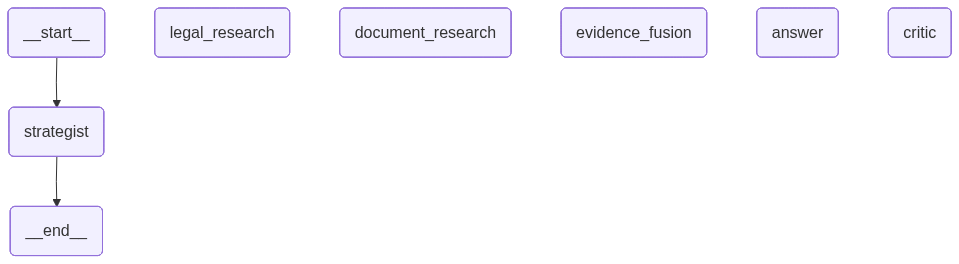

In [20]:
from IPython.display import Image, display

display(Image(legal_graph.get_graph().draw_mermaid_png()))

In [21]:
def legal_agentic_rag(question, uploaded_file=None):

    vector_store = None

    if uploaded_file:
        vector_store = load_uploaded_document(uploaded_file)

    state = {
        "question": question,
        "graph_vector_store": vector_store
    }

    result = legal_graph.invoke(state)

    return result["answer"]

In [26]:
evaluation_dataset = [

    {
        "question": "If a state law conflicts with a central law in India, which prevails?",
        "ground_truth": "Central law prevails under Article 254 of the Indian Constitution."
    },

    {
        "question": "Which article guarantees equality before law?",
        "ground_truth": "Article 14 guarantees equality before law."
    },

    {
        "question": "Which article of the Constitution deals with freedom of speech?",
        "ground_truth": "Article 19 guarantees freedom of speech and expression."
    }

]

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

def answer_similarity(answer, ground_truth):

    answer_emb = embeddings.embed_query(answer)
    truth_emb = embeddings.embed_query(ground_truth)

    score = cosine_similarity(
        [answer_emb],
        [truth_emb]
    )[0][0]

    return float(score)

In [24]:
def hallucination_check(question, answer):

    prompt = f"""
You are evaluating whether an answer is grounded in factual knowledge.

Question:
{question}

Answer:
{answer}

Does the answer contain hallucinated or fabricated information?

Reply with only:
PASS
or
FAIL
"""

    result = llm.invoke(prompt).content.strip().upper()

    if "PASS" in result:
        return "PASS"
    else:
        return "FAIL"

In [25]:
# evaluation

def evaluate_rag_system(dataset):

    results = []

    for sample in dataset:

        question = sample["question"]
        ground_truth = sample["ground_truth"]

        state = {"question": question, "graph_vector_store": None}

        result = legal_graph.invoke(state)

        answer = result["answer"]

        similarity = answer_similarity(answer, ground_truth)

        hallucination = hallucination_check(question, answer)

        results.append({
            "question": question,
            "similarity": similarity,
            "hallucination": hallucination
        })

        print("\nQuestion:", question)
        print("Answer:", answer)
        print("Similarity:", similarity)
        print("Hallucination:", hallucination)

    return results

In [27]:
evaluation_results = evaluate_rag_system(evaluation_dataset)


Question: If a state law conflicts with a central law in India, which prevails?
Answer: In the context of Indian law, if a state law conflicts with a central law, the central law prevails. This is based on the doctrine of federal supremacy, which is enshrined in Article 254 of the Indian Constitution. According to this article, if a state law is inconsistent with a central law, the central law will prevail, and the state law will be void to the extent of the inconsistency.
Similarity: 0.7380788216892062
Hallucination: PASS

Question: Which article guarantees equality before law?
Answer: Based on general legal knowledge, Article 14 of the Constitution of India guarantees equality before the law. This article states that "The State shall not deny to any person equality before the law or the equal protection of the laws within the territory of India." 

However, without specific context, it's also possible that a similar provision exists in other countries' constitutions. For example, th

In [28]:
def summarize_results(results):

    similarity_scores = [r["similarity"] for r in results]

    hallucinations = [
        1 if r["hallucination"] == "PASS" else 0
        for r in results
    ]

    print("\n--- RAG PERFORMANCE SUMMARY ---\n")

    print("Average Answer Similarity:",
          sum(similarity_scores) / len(similarity_scores))

    print("Grounded Answer Rate:",
          sum(hallucinations) / len(hallucinations))

In [29]:
summarize_results(evaluation_results)


--- RAG PERFORMANCE SUMMARY ---

Average Answer Similarity: 0.7384114911366656
Grounded Answer Rate: 1.0


#### RAGAS EVALUATION

automatic RAG benchmarking using the framework RAGAS, which calculates 5 evaluation metrics automatically and would make your notebook look like a research-grade evaluation pipeline.

In [34]:
from datasets import Dataset

from ragas import evaluate

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

ragas_llm = LangchainLLMWrapper(llm)

ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
    answer_correctness
)

C:\Users\user\AppData\Local\Temp\ipykernel_2760\1866035038.py:8: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(llm)
C:\Users\user\AppData\Local\Temp\ipykernel_2760\1866035038.py:10: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)
C:\Users\user\AppData\Local\Temp\ipykernel_2760\1866035038.py:12: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collect

In [35]:
def build_ragas_dataset(dataset):

    questions = []
    answers = []
    contexts = []
    ground_truths = []

    for sample in dataset:

        question = sample["question"]
        ground_truth = sample["ground_truth"]

        state = {"question": question, "graph_vector_store": None}

        result = legal_graph.invoke(state)

        answer = result["answer"]

        docs = result.get("final_docs", [])

        retrieved_contexts = [
            d.page_content for d in docs
        ]

        questions.append(question)
        answers.append(answer)
        contexts.append(retrieved_contexts)
        ground_truths.append(ground_truth)

    ragas_dataset = Dataset.from_dict({
        "question": questions,
        "answer": answers,
        "contexts": contexts,
        "ground_truth": ground_truths
    })

    return ragas_dataset

In [36]:
ragas_dataset = build_ragas_dataset(evaluation_dataset)

In [37]:
result = evaluate(
    ragas_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
        answer_correctness
    ],
    llm=ragas_llm,
    embeddings=ragas_embeddings
)

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

Exception raised in Job[5]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99930, Requested 496. Please try again in 6m8.063999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}})
Exception raised in Job[10]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99888, Requested 464. Please try again in 5m4.128s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}})
Exception raised in Job[0]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate li

In [38]:
print(result)

{'faithfulness': nan, 'answer_relevancy': nan, 'context_precision': 0.0000, 'context_recall': nan, 'answer_correctness': nan}
